<Figure size 2400x1800 with 0 Axes>

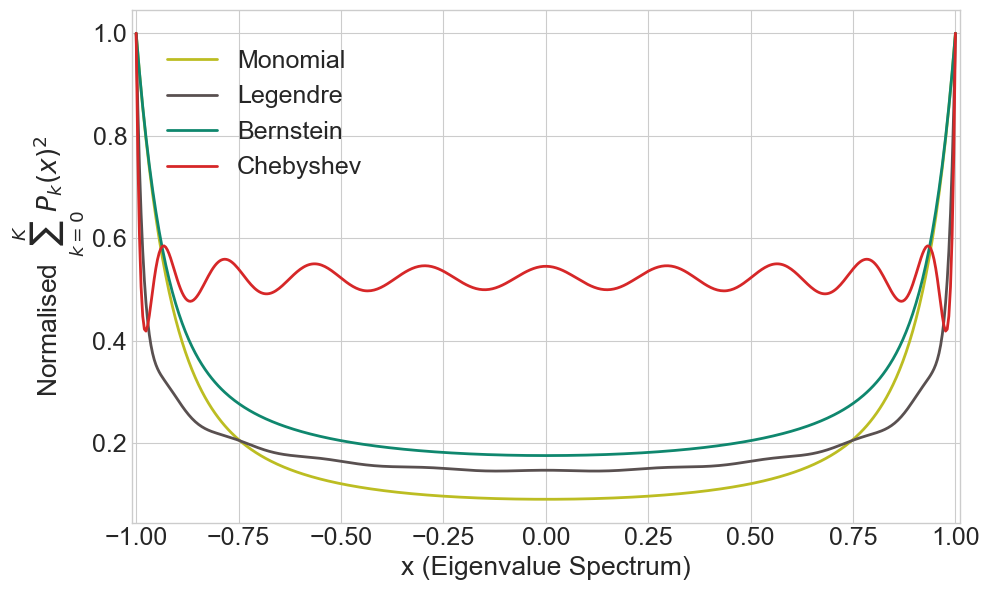

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_chebyt, eval_legendre, comb

def calculate_monomial_sum(x, K):
    """Calculates the sum of squares for the Monomial basis."""
    total_sum = np.zeros_like(x)
    for k in range(K + 1):
        total_sum += (x**k)**2
    total_sum = total_sum/total_sum[0]
    return total_sum

def calculate_chebyshev_sum(x, K):
    """Calculates the sum of squares for the Chebyshev basis (1st kind)."""
    total_sum = np.zeros_like(x)
    for k in range(K + 1):
        total_sum += eval_chebyt(k, x)**2 
    total_sum = total_sum/total_sum[0]
    return total_sum

def calculate_legendre_sum(x, K):
    """Calculates the sum of squares for the Legendre basis."""
    total_sum = np.zeros_like(x)
    for k in range(K + 1):
        total_sum += eval_legendre(k, x)**2
    total_sum = total_sum/total_sum[0]
    return total_sum

def calculate_bernstein_sum(x, K):
    """Calculates the sum of squares for the Bernstein basis."""
    # Bernstein basis is defined on [0, 1], so we rescale x from [-1, 1]
    t = (x + 1.0) / 2.0
    total_sum = np.zeros_like(t)
    for k in range(K + 1):
        bernstein_poly = comb(K, k) * (t**k) * ((1 - t)**(K - k))
        total_sum += bernstein_poly**2
    # Normalize to match the other bases at x=-1 (t=0)
    total_sum = total_sum / total_sum[0]
    return total_sum


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Create figure with optimal size
plt.figure(figsize=(8, 6), dpi=300)

# Set style parameters
plt.rcParams.update({
    'axes.labelsize': 19,
    'axes.titlesize': 19,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'lightgray',
    'axes.facecolor': 'white',
    'axes.grid': False
})

colors = {
    "bernstein": "#0F876E",
    "chebyshev": "#d62728",
    "legendre": "#595050",
    "monomial": "#bcbd22",
}

# --- Parameters ---
K = 10 # Degree of the polynomial
N_POINTS = 500 # Number of points to plot
x = np.linspace(-1.0, 1.0, N_POINTS)

# --- Calculate sums for each basis ---
monomial_sum = calculate_monomial_sum(x, K)
chebyshev_sum = calculate_chebyshev_sum(x, K)
legendre_sum = calculate_legendre_sum(x, K)
bernstein_sum = calculate_bernstein_sum(x, K)

K2 = 20
monomial_sum2 = calculate_monomial_sum(x, K2)
chebyshev_sum2 = calculate_chebyshev_sum(x, K2)
legendre_sum2 = calculate_legendre_sum(x, K2)
bernstein_sum2 = calculate_bernstein_sum(x, K2)

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))



ax.plot(x, monomial_sum, label='Monomial', color=colors["monomial"], linewidth=2)
ax.plot(x, legendre_sum, label='Legendre', color=colors["legendre"], linewidth=2)
ax.plot(x, bernstein_sum, label='Bernstein', color=colors["bernstein"], linewidth=2)
ax.plot(x, chebyshev_sum, label='Chebyshev', color=colors["chebyshev"], linewidth=2)

ax.set_xlabel('x (Eigenvalue Spectrum)')
ax.set_ylabel("Normalised " + r'$\sum_{k=0}^{K} P_k(x)^2$')
ax.legend(loc=[0.03, 0.65])
ax.tick_params(axis='both', which='major')
ax.set_xlim([-1.01, 1.01])

plt.tight_layout()